<a href="https://colab.research.google.com/github/seisbench/seisbench/blob/additional_example_workflows/examples/01b_model_api.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

![image](https://raw.githubusercontent.com/seisbench/seisbench/main/docs/_static/seisbench_logo_subtitle_outlined.svg)

*This code is necessary on colab to install SeisBench. If SeisBench is already installed on your machine, you can skip this.*

run with seisbench conda environment 

In [4]:
try:
    import obspy
    obspy.read()
except TypeError:
    # Needs to restart the runtime once, because obspy only works properly after restart.
    print('Stopping RUNTIME. If you run this code for the first time, this is expected. Colaboratory will restart automatically. Please run again.')
    exit()
from obspy import read, UTCDateTime

#%load_ext autoreload
#%autoreload 2
#%matplotlib inline 
#%matplotlib widget

# Model API

This tutorial introduces the SeisBench model API. It explains how to load pretrained models and apply them to generate characteristic curves or discrete picks.

**Note:** Some familiarity with obspy is helpful for this tutorial, but not required.

In [5]:
import seisbench
import seisbench.models as sbm

### Loading pretrained models

The model created above consisted of random weights, i.e., it was not trained. While this is (often) the right approach when starting to train a model, for application we'll need a trained model. SeisBench offers pretrained models, which can be loaded with the `from_pretrained` method. To list available pretrained models, we can use `list_pretrained`. By setting `details=True`, we also get a docstring for each model.

In [6]:
pretrained_weights = sbm.PhaseNet.list_pretrained(details=True)
for key, value in pretrained_weights.items():
    print(f"{key}:\n{value}\n-----------------------\n")

diting:
Model trained on the DiTing dataset, a large-scale Chinese seismic benchmark dataset.
For models fine-tuned on individual regions in China, please see: https://github.com/JUNZHU-SEIS/USTC-Pickers
If you use this model, please reference: Zhu J, Li ZF and Fang LH (2023). USTC-Pickers: a Unified Set of seismic phase pickers Transfer learned for China. Earthq Sci 36(2): 95–112, doi: 10.1016/j.eqs.2023.03.001
-----------------------

ethz:
Model trained on ETHZ for 100 epochs with a learning rate of 0.01.
Threshold selected for optimal F1 score on in-domain evaluation. Depending on the target region, the thresholds might need to be adjusted.
When using this model, please reference the SeisBench publications listed at https://github.com/seisbench/seisbench

Jannes Münchmeyer, Jack Woollam (munchmej@gfz-potsdam.de, jack.woollam@kit.edu)
-----------------------

geofon:
Model trained on GEOFON for 100 epochs with a learning rate of 0.001.
Threshold selected for optimal F1 score on in-d

We are going to load the model from Zhu et al. (2018) that was trained on examples from California. If the model is loaded for the first time, it will be downloaded from the SeisBench repository. The downloaded model is cached in the SeisBench cache. Pretrained models also have docstrings, describing the model.

In [7]:
model = sbm.PhaseNet.from_pretrained("geofon")
print(model.weights_docstring)

Downloading: 100%|██████████| 1.06M/1.06M [00:00<00:00, 5.44MB/s]


Model trained on GEOFON for 100 epochs with a learning rate of 0.001.
Threshold selected for optimal F1 score on in-domain evaluation. Depending on the target region, the thresholds might need to be adjusted.
When using this model, please reference the SeisBench publications listed at https://github.com/seisbench/seisbench

Jannes Münchmeyer, Jack Woollam (munchmej@gfz-potsdam.de, jack.woollam@kit.edu)


/Users/tnm/anaconda3/envs/seisbench/lib/python3.11/site-packages/seisbench/models/base.py:489: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_weights = torch.load(f"{pa

### Annotating waveform streams: Seisbench Example data

SeisBench models can directly annotate obspy streams. Let's download a 200 s long piece of waveforms from a station in Chile through FDSN and visualize it.

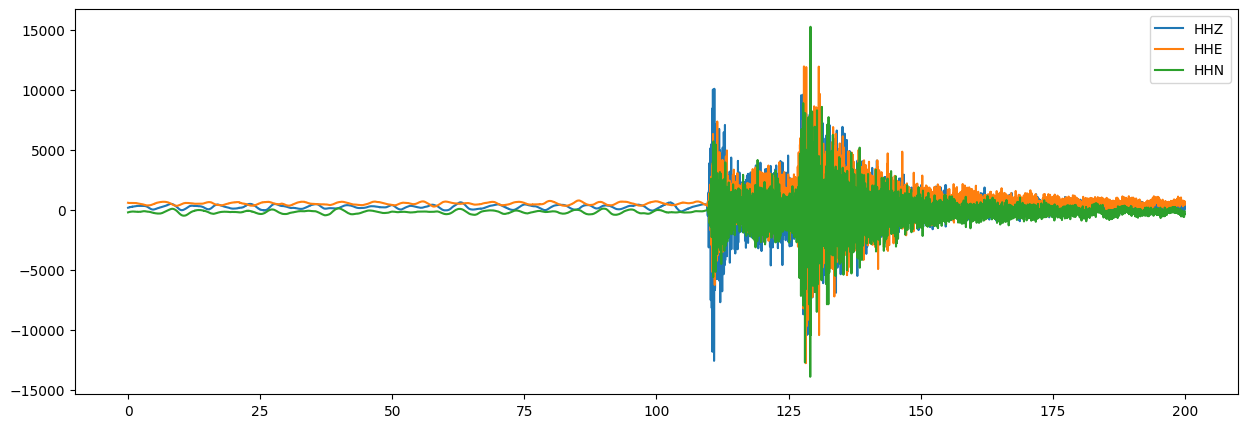

In [8]:
from obspy.clients.fdsn import Client
from obspy import UTCDateTime
import matplotlib.pyplot as plt

client = Client("GFZ")

t = UTCDateTime("2007/01/02 05:48:50")
stream = client.get_waveforms(network="CX", station="PB01", location="*", channel="HH?", starttime=t-100, endtime=t+100)

fig = plt.figure(figsize=(15, 5))
ax = fig.add_subplot(111)
for i in range(3):
    ax.plot(stream[i].times(), stream[i].data, label=stream[i].stats.channel)
ax.legend()

SeisBench models can generate characteristic curves, i.e., curves providing the probability of a pick at a certain time. For this, the annotate function is used. Annotate automatically transforms the trace into a compatible format for the model and merges the preditions into traces. For example, annotate will determine the correct component order and resample the trace to the required sampling rate.

In [9]:
annotations = model.annotate(stream)
print(annotations)

3 Trace(s) in Stream:
CX.PB01..PhaseNet_P | 2007-01-02T05:47:12.500000Z - 2007-01-02T05:50:27.500000Z | 100.0 Hz, 19501 samples
CX.PB01..PhaseNet_S | 2007-01-02T05:47:12.500000Z - 2007-01-02T05:50:27.500000Z | 100.0 Hz, 19501 samples
CX.PB01..PhaseNet_N | 2007-01-02T05:47:12.500000Z - 2007-01-02T05:50:27.500000Z | 100.0 Hz, 19501 samples


`annotate` takes additional, optional arguments that depend on the specific model and are documented in the model defintion. For example, PhaseNet is applied with a sliding window approach and therefore has a `overlap` parameter, indicating the overlap in samples between two consequtive applications of the model. Let's try out a different overlap.

In [10]:
annotations = model.annotate(stream, overlap=2000)
print(annotations)

3 Trace(s) in Stream:
CX.PB01..PhaseNet_P | 2007-01-02T05:47:12.500000Z - 2007-01-02T05:50:27.500000Z | 100.0 Hz, 19501 samples
CX.PB01..PhaseNet_S | 2007-01-02T05:47:12.500000Z - 2007-01-02T05:50:27.500000Z | 100.0 Hz, 19501 samples
CX.PB01..PhaseNet_N | 2007-01-02T05:47:12.500000Z - 2007-01-02T05:50:27.500000Z | 100.0 Hz, 19501 samples


You might have also noticed that the annotation process took a bit longer, because PhaseNet was applied more often than with the default overlap.

Let's visualize the predictions alongside the waveforms. As we can see, PhaseNet correctly identified the P and S arrival of the main event. Note that the confidence values (the peaks of the probability curves) are high, but not quite 1. This is common for deep learning based picking models.

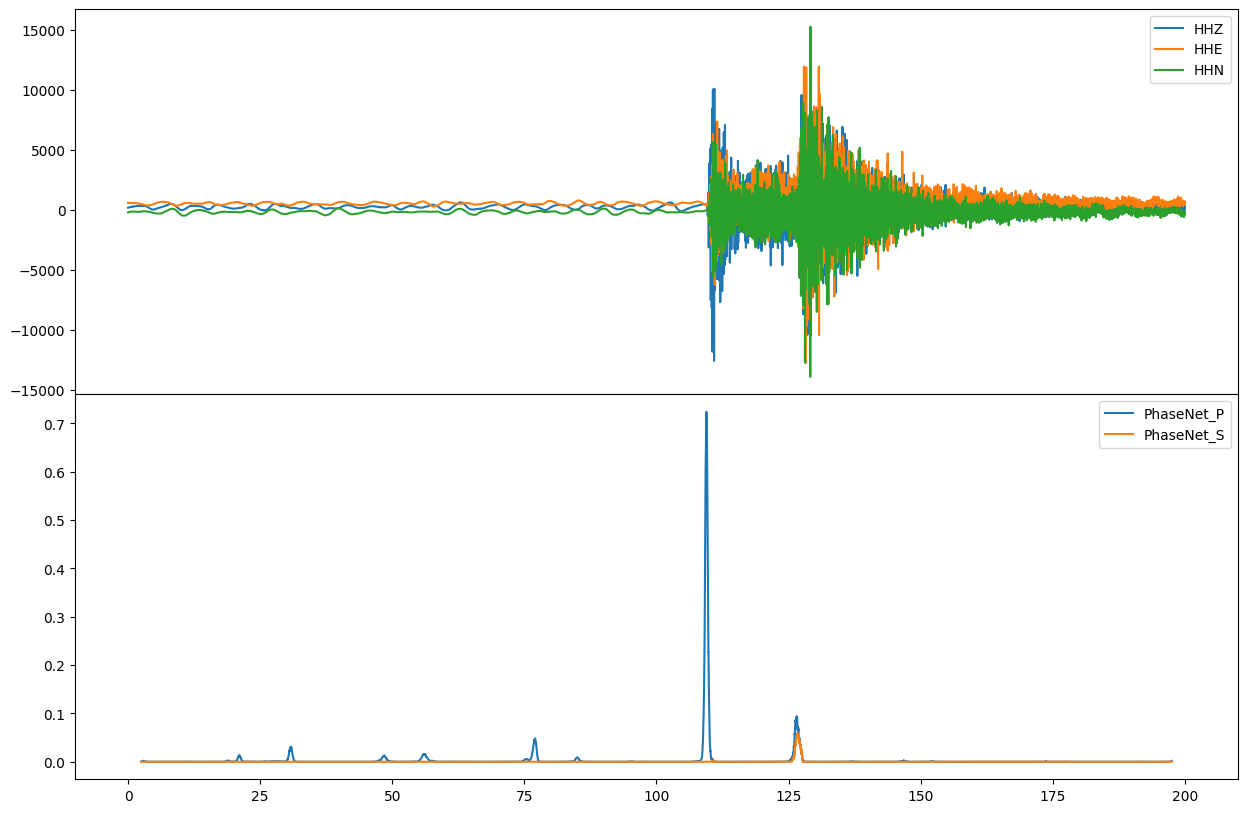

In [11]:
fig = plt.figure(figsize=(15, 10))
axs = fig.subplots(2, 1, sharex=True, gridspec_kw={'hspace': 0})

offset = annotations[0].stats.starttime - stream[0].stats.starttime
for i in range(3):
    axs[0].plot(stream[i].times(), stream[i].data, label=stream[i].stats.channel)
    if annotations[i].stats.channel[-1] != "N":  # Do not plot noise curve
        axs[1].plot(annotations[i].times() + offset, annotations[i].data, label=annotations[i].stats.channel)

axs[0].legend()
axs[1].legend()

In addition to the `annotate` function, SeisBench models offer the `classify` function. This function returns discrete objects, in this case, picks. Again, we can pass configuration parameters to the function. Here, we provide detection thresholds. Let's first print all outputs together.

In [12]:
output = model.classify(stream, P_threshold=0.5, S_threshold=0.5)
print(output)

ClassifyOutput(creator='PhaseNet', picks=PickList with 1 entries:

CX.PB01.	2007-01-02T05:48:59.420000Z	P)


Alternatively, we can access the picks separately. The picks are a simple list that can be iterated over or access through indexing.

In [13]:
print(output.picks)

PickList with 1 entries:

CX.PB01.	2007-01-02T05:48:59.420000Z	P


### Saint data

In [14]:
# Various pre-trained weights for PhaseNet
pn_model = sbm.PhaseNet.from_pretrained("ethz")
# pn_model = sbm.PhaseNet.from_pretrained("instance")
# pn_model = sbm.PhaseNet.from_pretrained("scedc")
# pn_model = sbm.PhaseNet.from_pretrained("stead")
# pn_model = sbm.PhaseNet.from_pretrained("geofon")
# pn_model = sbm.PhaseNet.from_pretrained("neic")

# Various pre-trained weights for EQT
eqt_model = sbm.EQTransformer.from_pretrained("original")
# eqt_model = sbm.EQTransformer.from_pretrained("ethz")
# eqt_model = sbm.EQTransformer.from_pretrained("instance")
# eqt_model = sbm.EQTransformer.from_pretrained("scedc")
# eqt_model = sbm.EQTransformer.from_pretrained("stead")
# eqt_model = sbm.EQTransformer.from_pretrained("geofon")

# Various pre-trained weights for GPD
# gpd_model = sbm.GPD.from_pretrained("original")
gpd_model = sbm.GPD.from_pretrained("ethz")
# gpd_model = sbm.GPD.from_pretrained("scedc")
# gpd_model = sbm.GPD.from_pretrained("stead")
# gpd_model = sbm.GPD.from_pretrained("geofon")
# gpd_model = sbm.GPD.from_pretrained("neic")

Downloading: 100%|██████████| 1.06M/1.06M [00:00<00:00, 2.87MB/s]
/Users/tnm/anaconda3/envs/seisbench/lib/python3.11/site-packages/seisbench/models/base.py:489: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues relate

Change the sampling rate to make the traces higher or lower freq?


2024-09-10 11:59:33,467 | seisbench | WARNING | Parts of the input stream consist of fragments shorter than the number of input samples or misaligned traces. Output might be empty.
2024-09-10 11:59:33,476 | seisbench | WARNING | Parts of the input stream consist of fragments shorter than the number of input samples or misaligned traces. Output might be empty.


         network: BW
         station: RJOB
        location: 
         channel: EHZ
       starttime: 2009-08-24T00:20:06.000000Z
         endtime: 2009-08-24T00:20:11.000000Z
   sampling_rate: 100.0
           delta: 0.01
            npts: 501
           calib: 1.0
    back_azimuth: 100.0
     inclination: 30.0
      processing: ['ObsPy 1.4.1: trim(endtime=UTCDateTime(2009, 8, 24, 0, 20, 11)::fill_value=None::nearest_sample=True::pad=False::starttime=UTCDateTime(2009, 8, 24, 0, 20, 6))']
        response: Channel Response
	From M/S (Velocity in Meters Per Second) to COUNTS (Digital Counts)
	Overall Sensitivity: 2.5168e+09 defined at 0.020 Hz
	4 stages:
		Stage 1: PolesZerosResponseStage from M/S to V, gain: 1500
		Stage 2: CoefficientsTypeResponseStage from V to COUNTS, gain: 1.67785e+06
		Stage 3: FIRResponseStage from COUNTS to COUNTS, gain: 1
		Stage 4: FIRResponseStage from COUNTS to COUNTS, gain: 1
0 Trace(s) in Stream:
 0 Trace(s) in Stream:
 3 Trace(s) in Stream:
BW.RJOB..GPD_

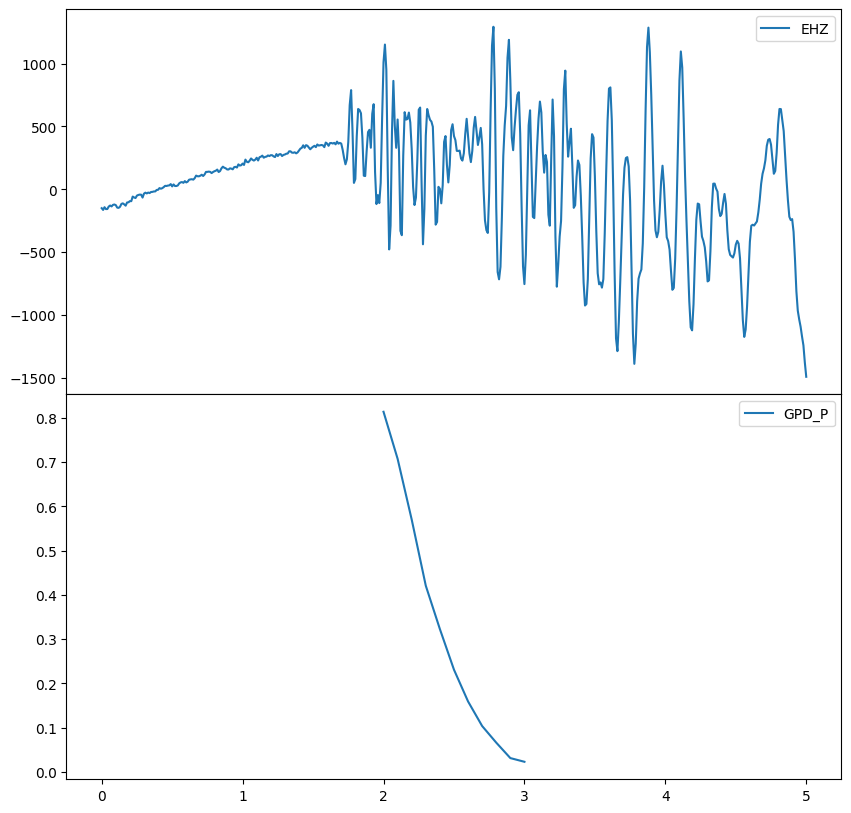

In [15]:
st_exp = read()
st_exp.trim(st_exp[0].stats.starttime+3, st_exp[0].stats.starttime+8)
print(st_exp[0].stats)
# plt.figure()
# plt.plot(st_exp[0].data)
# plt.show()

st_exp.remove(st_exp[1])
st_exp.remove(st_exp[1])

pn_preds = pn_model.annotate(st_exp, overlap=10)
eqt_preds = eqt_model.annotate(st_exp, overlap=10)
gpd_preds = gpd_model.annotate(st_exp, overlap=10)

print(pn_preds, eqt_preds, gpd_preds)

fig = plt.figure(figsize=(10, 10))
axs = fig.subplots(2, 1, sharex=True, gridspec_kw={'hspace': 0})

axs[0].plot(st_exp[0].times(), st_exp[0].data, label=st_exp[0].stats.channel)

if len(gpd_preds)>0: 
    offset = gpd_preds[0].stats.starttime - st_exp[0].stats.starttime
    axs[1].plot(gpd_preds[0].times() + offset, gpd_preds[0].data, label=gpd_preds[0].stats.channel)
if len(eqt_preds)>0:  
    offset = eqt_preds[0].stats.starttime - st_exp[0].stats.starttime
    axs[1].plot(eqt_preds[0].times() + offset, eqt_preds[0].data, label=eqt_preds[0].stats.channel)
if len(pn_preds)>0:
    offset = pn_preds[0].stats.starttime - st_exp[0].stats.starttime
    axs[1].plot(pn_preds[0].times() + offset, pn_preds[0].data, label=pn_preds[0].stats.channel)

axs[0].legend()
axs[1].legend()

In [16]:
gpd_preds[0]

BW.RJOB..GPD_P | 2009-08-24T00:20:08.000000Z - 2009-08-24T00:20:09.000000Z | 10.0 Hz, 11 samples

         network: SH
         station: 31433
        location: 
         channel: 
       starttime: 2024-06-06T18:15:00.000000Z
         endtime: 2024-06-06T18:15:01.000000Z
   sampling_rate: 500.0
           delta: 0.002
            npts: 501
           calib: 1.0
         _format: MSEED
           mseed: AttribDict({'dataquality': 'D', 'number_of_records': 3565, 'encoding': 'FLOAT32', 'byteorder': '>', 'record_length': 4096, 'filesize': 14602240})
      processing: ['ObsPy 1.4.1: trim(endtime=UTCDateTime(2024, 6, 6, 18, 15, 1)::fill_value=None::nearest_sample=True::pad=False::starttime=UTCDateTime(2024, 6, 6, 18, 15))']
0 Trace(s) in Stream:
 0 Trace(s) in Stream:
 0 Trace(s) in Stream:



/var/folders/7m/t7cq9k2x4z1fyhvk4jrk_5k80000gn/T/ipykernel_51501/2254177306.py:31: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[1].legend()


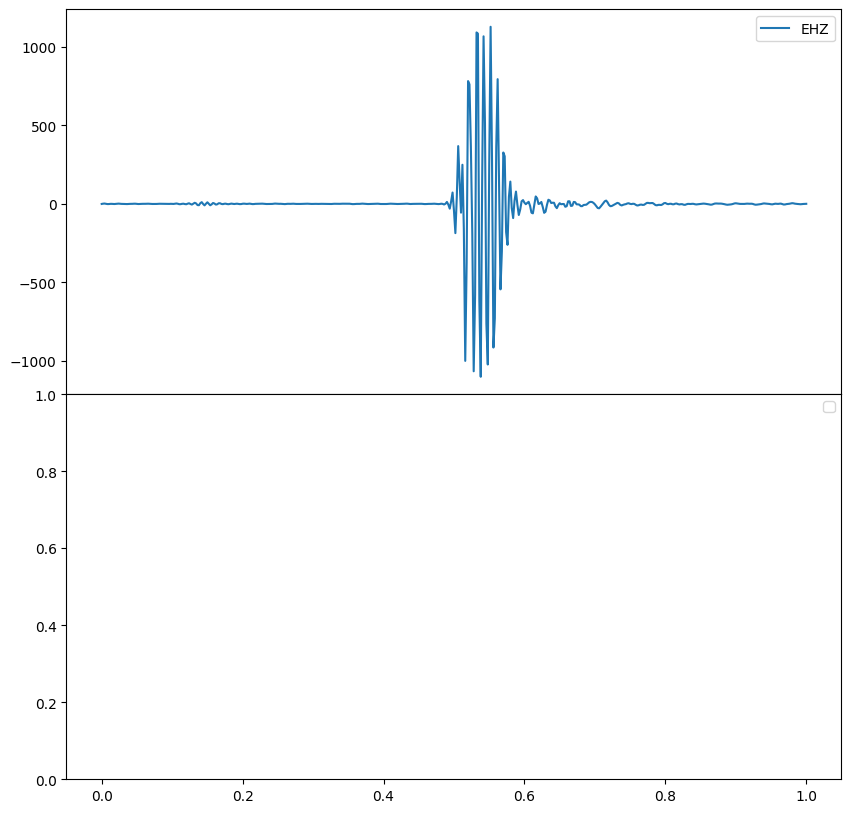

In [17]:

st_saint = read("31433_soulton_hall.mseed")
st_saint[0].data = st_saint[0].data * 2000  # as large amplitude as the other example
st_saint[0].resample = 100  # as large amplitude as the other example
st_saint.trim(UTCDateTime("2024-06-06T18:15:00.000000Z"), UTCDateTime("2024-06-06T18:15:01.000000Z"))

print(st_saint[0].stats)


pn_preds = pn_model.annotate(st_saint, overlap=50)
eqt_preds = eqt_model.annotate(st_saint, overlap=50)
gpd_preds = gpd_model.annotate(st_saint, overlap=50)

print(pn_preds, eqt_preds, gpd_preds)

fig = plt.figure(figsize=(10, 10))
axs = fig.subplots(2, 1, sharex=True, gridspec_kw={'hspace': 0})

axs[0].plot(st_saint[0].times(), st_saint[0].data, label=st_exp[0].stats.channel)

if len(gpd_preds)>0: 
    offset = gpd_preds[0].stats.starttime - st_exp[0].stats.starttime
    axs[1].plot(gpd_preds[0].times() + offset, gpd_preds[0].data, label=gpd_preds[0].stats.channel)
if len(eqt_preds)>0:  
    offset = eqt_preds[0].stats.starttime - st_exp[0].stats.starttime
    axs[1].plot(eqt_preds[0].times() + offset, eqt_preds[0].data, label=eqt_preds[0].stats.channel)
if len(pn_preds)>0:
    offset = pn_preds[0].stats.starttime - st_exp[0].stats.starttime
    axs[1].plot(pn_preds[0].times() + offset, pn_preds[0].data, label=pn_preds[0].stats.channel)

axs[0].legend()
axs[1].legend()


In [18]:
# st_saint.remove(st_saint[1])
# st_saint.remove(st_saint[1])

pn_preds = pn_model.annotate(st_saint, overlap=500)
eqt_preds = eqt_model.annotate(st_saint, overlap=500)
gpd_preds = gpd_model.annotate(st_saint, overlap=500)

pn_preds, eqt_preds, gpd_preds

(0 Trace(s) in Stream:
, 0 Trace(s) in Stream:
, 0 Trace(s) in Stream:
)

IndexError: list index out of range

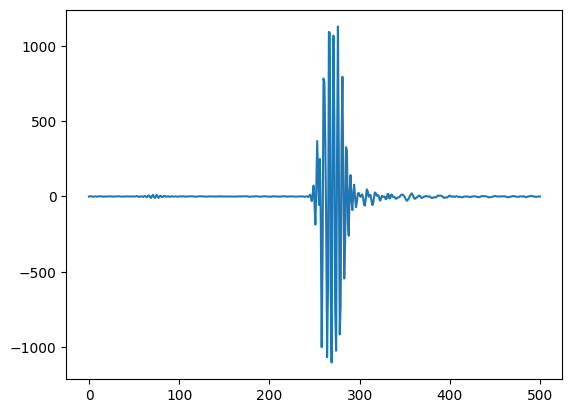

In [19]:
plt.figure()
plt.plot(st_saint[0].data)
plt.plot(gpd_preds[0].data)
plt.plot(gpd_preds[1].data)
plt.plot(gpd_preds[2].data)
plt.show()

In [ ]:
annotations = model.annotate(st_saint)
print(annotations)


2024-08-30 21:16:41,966 | seisbench | WARNING | Parts of the input stream consist of fragments shorter than the number of input samples or misaligned traces. Output might be empty.


0 Trace(s) in Stream:

